In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [2]:
from pyhgf.model import Network
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
from jax import config
from models import (
    bayesian_psychophysics,
    cardiac_believing,
    weighted_update,
    sample_cardiac_hgf,
)

config.update("jax_enable_x64", True)

plt.rcParams["figure.constrained_layout.use"] = True

In [3]:
participant_id = "sub-0019"
session = 1

In [4]:
# load and filter the data -------------------------------------------------------------
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)

In [5]:
if session == 1:
    hrd_df = hrd_df[
        (
            (hrd_df.cohort == "vmp1")
            & (hrd_df.task == "hrd-session1")
            & (hrd_df.participant_id == participant_id)
            & (~hrd_df.Decision.isnull())
        )
    ]
elif session == 2:
    hrd_df = hrd_df[
        (
            ((hrd_df.cohort == "vmp1") & (hrd_df.task == "hrd-session2"))
            | ((hrd_df.cohort == "vmp2") & (hrd_df.task == "hrd-session1"))
        )
        & (hrd_df.participant_id == participant_id)
        & (~hrd_df.Decision.isnull())
    ]

In [6]:
assert len(hrd_df) > 20

In [7]:
# extract variables of interest ------------------------------------------------------
heart_rate = hrd_df[hrd_df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = hrd_df[hrd_df.Modality == "Intero"].responseBPM.to_numpy()
intero_decision = (
    hrd_df[hrd_df.Modality == "Intero"].Decision.to_numpy() == "More"
).astype(int)

extero_tone_1 = hrd_df[hrd_df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = hrd_df[hrd_df.Modality == "Extero"].responseBPM.to_numpy()
extero_decision = (
    hrd_df[hrd_df.Modality == "Extero"].Decision.to_numpy() == "More"
).astype(int)
n = hrd_df.participant_id.nunique()

In [8]:
participant_codes_intero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Intero"].participant_id
).codes

participant_codes_extero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Extero"].participant_id
).codes

In [9]:
input_data_extero = np.array([extero_tone_1, extero_tone_2]).T
input_data_intero = np.array([heart_rate, intero_tone_2]).T

# Standard psychophysics

In [10]:
idata_bayesian_psychophysics, _ = bayesian_psychophysics(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.63,7
,2000,0,0.72,3
,2000,0,0.63,3
,2000,1,0.70,3


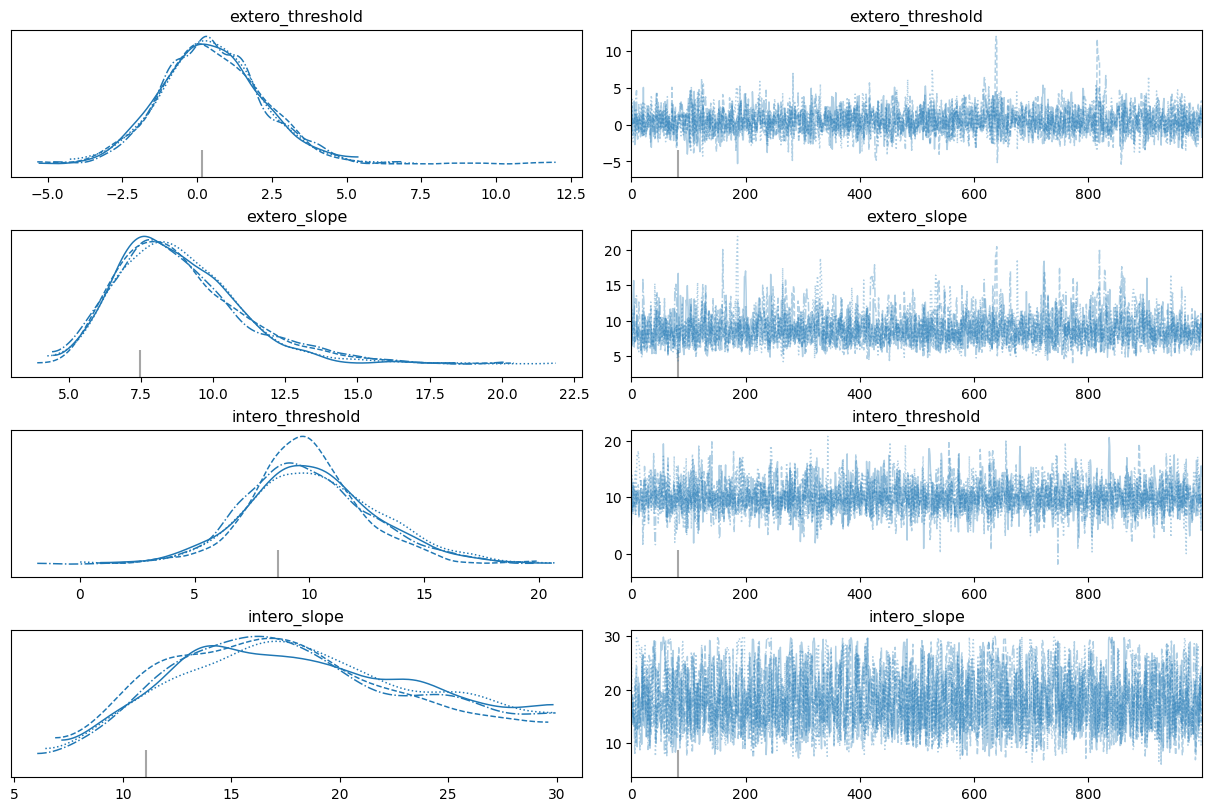

In [11]:
az.plot_trace(
    idata_bayesian_psychophysics,
    var_names=["extero_threshold", "extero_slope", "intero_threshold", "intero_slope"],
);

# Cardiac believing

In [12]:
idata_cardiac_believing, _ = cardiac_believing(
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.68,7
,2000,0,0.65,7
,2000,0,0.64,3
,2000,0,0.71,7


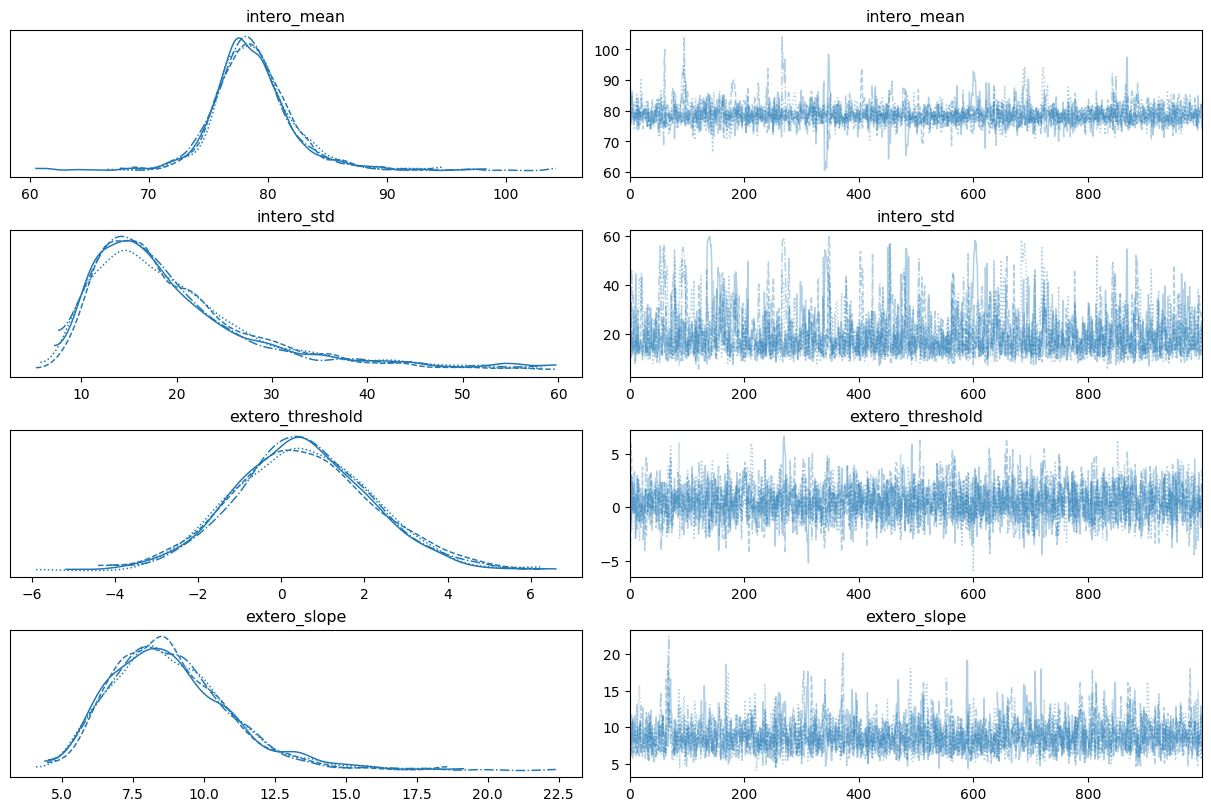

In [13]:
az.plot_trace(
    idata_cardiac_believing,
    var_names=[
        "intero_mean",
        "intero_std",
        "extero_threshold",
        "extero_slope",
    ],
);

# Weighted update

In [14]:
idata_weighted_update, _ = weighted_update(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.26,15
,2000,2,0.27,31
,2000,6,0.26,11
,2000,3,0.26,15


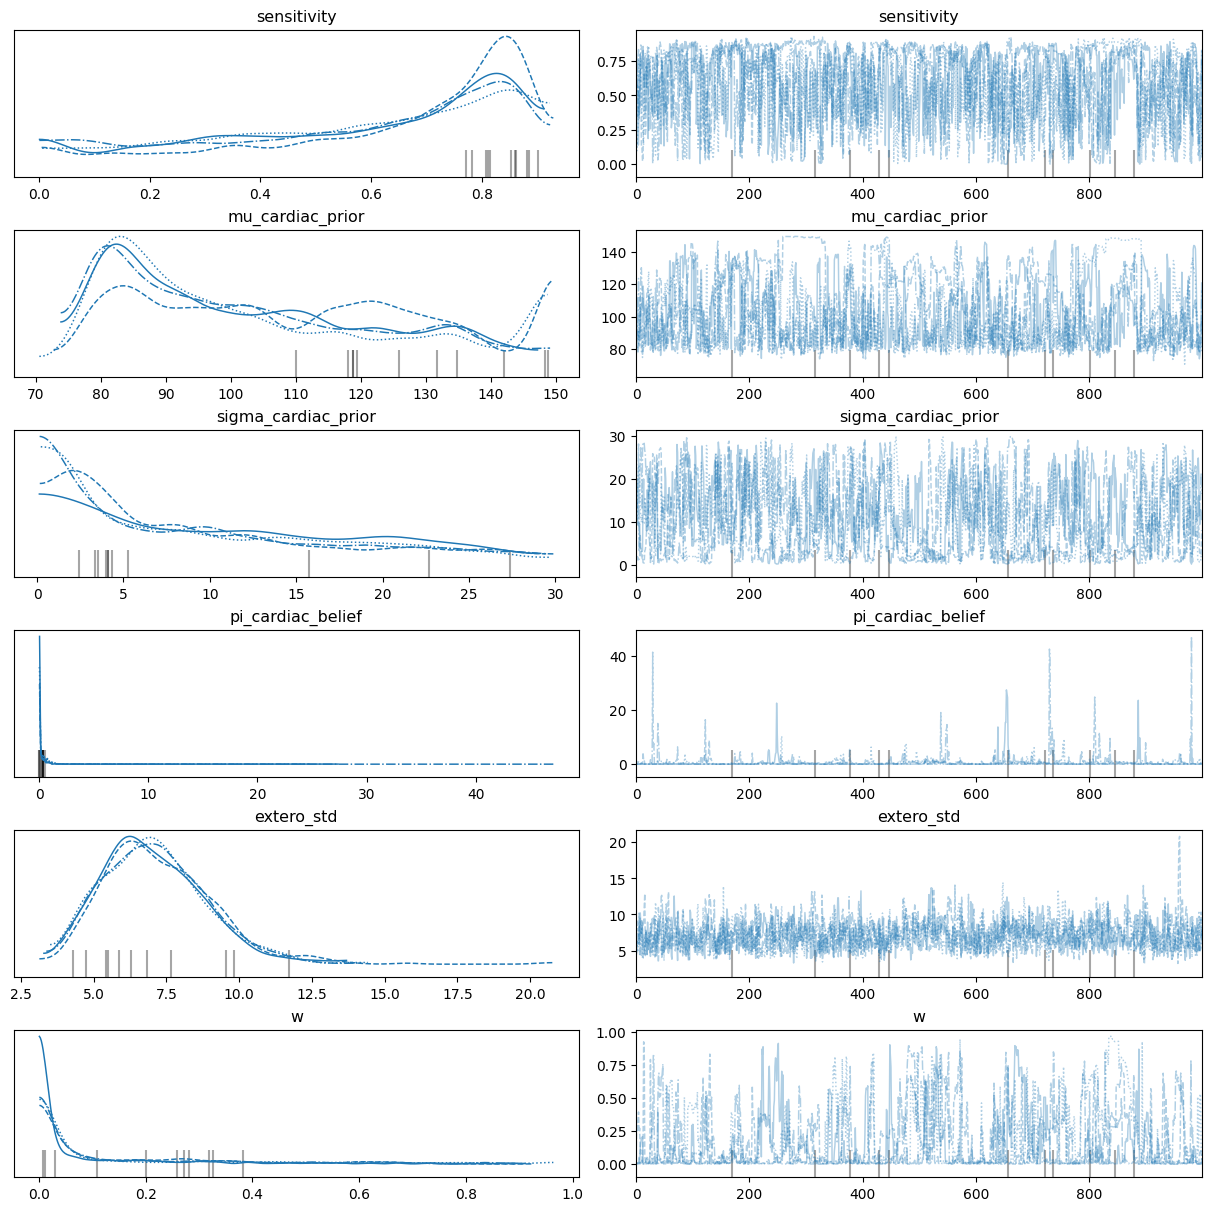

In [15]:
az.plot_trace(
    idata_weighted_update,
    var_names=[
        "sensitivity",
        "mu_cardiac_prior",
        "sigma_cardiac_prior",
        "pi_cardiac_belief",
        "extero_std",
        "w",
    ],
);

# Cardiac HGF

In [23]:
input_data_extero.mean()

np.float64(71.86875)

In [19]:
idata, model = sample_cardiac_hgf(
    input_data_extero=input_data_extero,
    input_data_intero=input_data_intero,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n_cores=4,
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [interoceptive_precision, exteroceptive_precision, interoceptive_tonic_volatility, exteroceptive_tonic_volatility, exteroceptive_mean, interoceptive_mean]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 86 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


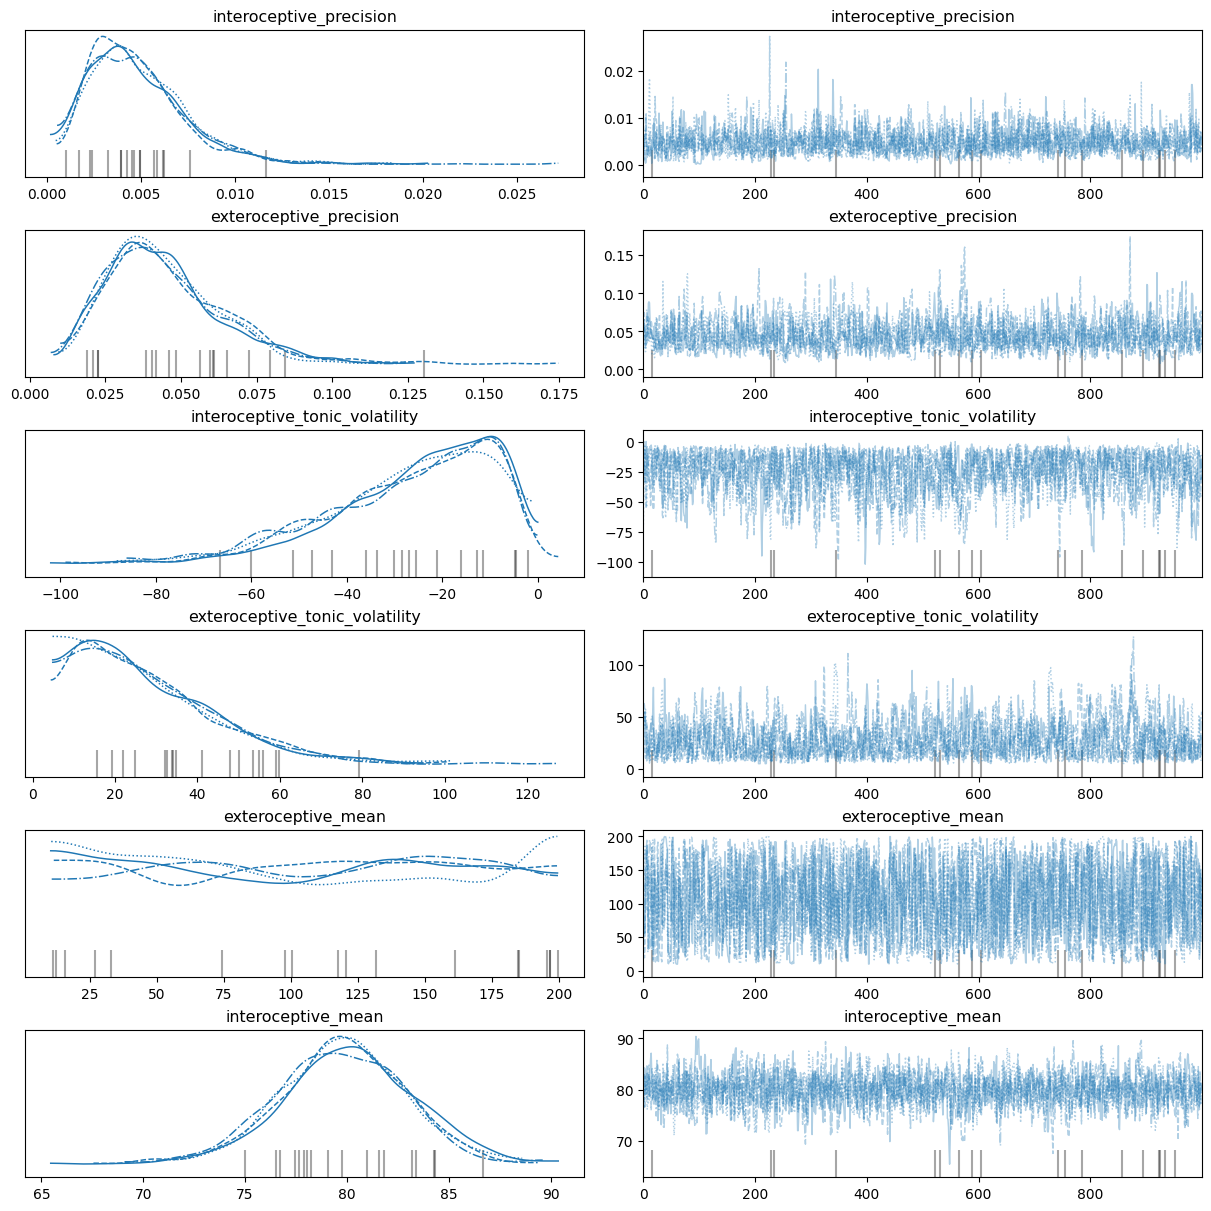

In [17]:
az.plot_trace(
    idata,
    var_names=[
        "interoceptive_precision",
        "exteroceptive_precision",
        "interoceptive_tonic_volatility",
        "exteroceptive_tonic_volatility",
        "exteroceptive_mean",
        "interoceptive_mean",
    ],
);